# Engineering of Data Analysis: assignment 1

By delivering this notebook, we confirm that the code presented was developed by the following students.

**Student num:** 65729     **; Eloi Lahondé:**

**Student num:** 67256     **; Milán Péter Novák**

**DEADLINE:** 21st April, 23h59

**Only one student should deliver the notebook**


**IMPORTANT:** To use GPUs in Colab, you need to go to the menu ```Edit > Notebook settings``` and select GPU as the hardware accelerator.

Some useful links:
* [ACM DEBS 2015 Grand Challenge](http://www.debs2015.org/call-grand-challenge.html)

* [Spark web site](https://spark.apache.org/)

* [Spark MLlib main page](https://spark.apache.org/mllib/)
* [Spark MLlib guide](https://spark.apache.org/docs/latest/ml-guide.html)

* [CuDF documentation](https://docs.rapids.ai/api/cudf/stable/)
* [cuML documentation](https://docs.rapids.ai/api/cuml/stable/)


# Install software

In [ ]:
# Install Spark
!apt-get install openjdk-17-jdk-headless
!pip install pyspark==4.0.0.dev2
!mkdir checkpoint


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  openjdk-17-jre-headless
Suggested packages:
  openjdk-17-demo openjdk-17-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-17-jdk-headless openjdk-17-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
Need to get 120 MB of archives.
After this operation, 271 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jre-headless amd64 17.0.14+7-1~22.04.1 [48.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jdk-headless amd64 17.0.14+7-1~22.04.1 [71.3 MB]
Fetched 120 MB in 5s (26.0 MB/s)
Selecting previously unselected package openjdk-17-jre-headless:amd64.
(Reading database ...

In [ ]:
# Software to download files
!pip install gdown

In [ ]:
# Install RAPIDS - for using cuDF, cuML
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible,
# it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 592 (delta 125), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (592/592), 194.79 KiB | 1.37 MiB/s, done.
Resolving deltas: 100% (299/299), done.
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pynvml.py", line 2415, in _LoadNvmlLibrary
    nvmlLib = CDLL("libnvidia-ml.so.1")
              ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvidia-ml.so.1: cannot open shared object file: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/rapidsai-csp-utils/colab/pip-install.py", line 18, in <module>
    

In [ ]:
import cudf, cuml
print("cuDF version:", cudf.__version__)
print("cuML version:", cuml.__version__)

/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


cuDF version: 25.02.01
cuML version: 25.02.01


# Setup

The data sets are available in the following link: https://drive.google.com/drive/folders/1WMwLUj0t4Q0GSll96lbF2bDjaPVh1w8z?usp=sharing. For running in Google Colab, you should access the link and Add Shortcut to your Drive.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# If you added the shortcut to your drive, the file should appear in this directory
# If not, you need to explore from directory /content/drive
!ls /content/drive/MyDrive/assignment1

Mounted at /content/drive
sample.csv.gz  sorted_data.csv.gz  tiny.csv.gz


Next cells setup: Pandas, Spark and cuDF/cuML.

In [ ]:
# General imports
import timeit

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster


In [ ]:
# Imports for Spark

import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# imports Spark SQL and Pandas API
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import *
from pyspark.ml.feature import *
import pyspark.pandas as ps

# this sets the maximum number of rows to show when printing pandas Dataframes
ps.set_option('display.max_rows', 10)



/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [ ]:
# Imports for cuDF / cuML

import cudf
import cupy as cp
import cuml.cluster

## Simple statistics

We will print some simple statistics.

In [ ]:
# Setup the dataset being used

# Large dataset - 12.3 GB compressed
#FILENAME = "/content/drive/MyDrive/assignment1/sorted_data.csv.gz"

# Small dataset - 135 MB compressed
FILENAME = "/content/drive/MyDrive/assignment1/sample.csv.gz"

# Tiny dataset - 6.8 MB compressed (you can use this one for speeding up development only)
#FILENAME = "/content/drive/MyDrive/assignment1/tiny.csv.gz"


In [ ]:
import matplotlib.pyplot as plt
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.linalg import Vectors

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Assignment 1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

start_time = time.time()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv", sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")

statistics = spark.sql( """SELECT COUNT( DISTINCT medallion) AS num_medallion,
                                  COUNT( DISTINCT hack_license) AS num_license,
                                  MIN( pickup_datetime) AS min_pickup,
                                  MAX( dropoff_datetime) AS max_dropoff,
                                  MAX( trip_time_in_secs) AS max_trip_time,
                                  MAX( trip_distance) AS max_trip_distance,
                                  MAX( total_amount) AS max_total_amount
                                  FROM data""")
#statistics.show()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 4.765648603439331


## Ploting information

Example on how to plot information using matplotlib.

### First plot

This first plot helps showing that data has several invalid values.

Let's plot the pickups.

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")

# Plotting all points is probably too much in many computers, so lets plot only a few 1000's
data = spark.sql( "SELECT * FROM data LIMIT 1000")
pickups = data.collect()

print('Plotting pickups')
plt.scatter([row.pickup_longitude for row in pickups],
            [row.pickup_latitude for row in pickups],
            s=1)
plt.show()


### Plotting heatamps

This example shows how to **plot heatmaps** and how to **create a grid** with coordinates -- note that we need to group nearby coordinates together or (almost) every coordinate will be unique.

The example creates a grid, with cell of 150m of side (commented out the code for cells of 500m of side).

\[From ACM DEBS 2015 Grand Challenge page\]

**Question 1**: Is the earth flat or how to map coordinates to cells?

**Answer**: For the challenge we allow a simplified flat earth assumption for mapping coordinates to cells in the queries. You can assume that a distance of 500 meter south corresponds to a change of 0.004491556 degrees in the coordinate system. For moving 500 meter east you can assume a change of 0.005986 degrees in the coordinate system.

In [ ]:
# Squares of 500 meters
#latitudeStep = 0.004491556
#longitudeStep = 0.005986
#northLatitude = 41.474937 - 0.5 * latitudeStep
#southLatitude = northLatitude - 300 * latitudeStep
#eastLongitude = -74.913585 - 0.5 * longitudeStep
#westLongitude = eastLongitude + 300 * longitudeStep

# Squares of 150 meters
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.2
westLongitude = eastLongitude + 300 * longitudeStep

# function to round longitude to a point in the middle of the square
def longiRound( val):
    return ((val - eastLongitude) // longitudeStep) * longitudeStep + eastLongitude + longitudeStep / 2
spark.udf.register("longround", longiRound, DoubleType())

# function to round latitude to a point in the middle of the square
def latRound( l):
    return northLatitude - ((northLatitude - l) // latitudeStep) * latitudeStep - latitudeStep / 2
spark.udf.register("latround", latRound, DoubleType())

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")

# Let's filter data outside of the box and build a grid
# Points in each square are mapped to the center of the square.
dataset.createOrReplaceTempView("data")
filteredDataDF = spark.sql( """SELECT medallion, hack_license, pickup_datetime,
                                    dropoff_datetime, trip_time_in_secs, trip_distance,
                                    longround(pickup_longitude) AS pickup_longitude,
                                    latround(pickup_latitude) AS pickup_latitude,
                                    longround(dropoff_longitude) AS dropoff_longitude,
                                    latround(dropoff_latitude) AS dropoff_latitude,
                                    payment_type, fare_amount, mta_tax,
                                    tip_amount, tolls_amount, total_amount
                                  FROM data
                                  WHERE pickup_longitude >= """ + str(eastLongitude) + """ AND
                                  pickup_longitude <=  """ + str(westLongitude) + """ AND
                                  dropoff_longitude >=  """ + str(eastLongitude) + """ AND
                                  dropoff_longitude <=  """ + str(westLongitude) + """ AND
                                  pickup_latitude <= """ + str(northLatitude) + """ AND
                                  pickup_latitude >= """ + str(southLatitude) + """ AND
                                  dropoff_latitude <=  """ + str(northLatitude) + """ AND
                                  dropoff_latitude >=  """ + str(southLatitude))
filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql( """SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY pickup_longitude, pickup_latitude""")
pickups = pickupsDF.collect()

print('Plotting pickups')
p = plt.scatter([row.pickup_longitude for row in pickups],
            [row.pickup_latitude for row in pickups],
            c=[row.cnt for row in pickups],s=1,cmap="rainbow")
plt.colorbar(p)
plt.show()

# Statistics for pickups
dropoffsDF = spark.sql( """SELECT dropoff_longitude, dropoff_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY dropoff_longitude, dropoff_latitude""")
dropoffs = dropoffsDF.collect()

print('Plotting pickups')
p = plt.scatter([row.dropoff_longitude for row in dropoffs],
            [row.dropoff_latitude for row in dropoffs],
            c=[row.cnt for row in dropoffs],s=1,cmap="rainbow")
plt.colorbar(p)
plt.show()



## Exercise 1: simple statistics

Compute, for each license, the total amount of money collected.

Comapre the time it takes to execute the code for Pandas, Spark Pandas API, Spark SQL and cuDF.

**Draw some conclusions** by comparing the time for performing the computation using Spark and Pandas, and also when using the small and long dataset.

### Code: Pandas library

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = pd.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 13.424361228942871


### Results (Pandas)

The time to process the small dataset was : **9.683083772659302** seconds.

The time to process the large dataset was : **FOREVER** seconds. It was impossible to process it, because there was not enough RAM.

### Code: Spark Pandas API

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = ps.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()
# force execution
result0 = result.to_spark().collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Runtime = 37.92714834213257


### Results (Spark Pandas API)

The time to process the small dataset was : **18.924025297164917** seconds.

The time to process the large dataset was : **FOREVER** seconds. We waited for 20 minutes, it didn't give an error. So we are guessing it will run at some point but don't have the patience to sit it out.

### Spark SQL

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

start_time = time.time()
mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT hack_license, SUM(total_amount) AS total_amount FROM data GROUP BY hack_license""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 7.745872974395752


### Results (Spark)

The time to process the small dataset was : **15.124377012252808** seconds.

The time to process the large dataset was : **Forever** seconds. Same problem as with the Pandas API.

### Code: cuDF

In [ ]:
start_time = time.time()
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

dataset = cudf.read_csv(FILENAME,names=mySchema)
result = dataset[["hack_license","total_amount"]].groupby("hack_license").sum()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


### Results (cuDF)

The time to process the small dataset was : **2.643967390060425** seconds.

The time to process the large dataset was : **The large dataset could not be processed, there was a problem with the decompression of the file. It can be a wrongly compressed file, or some version issue between cudf and zlib, or something more complex.**

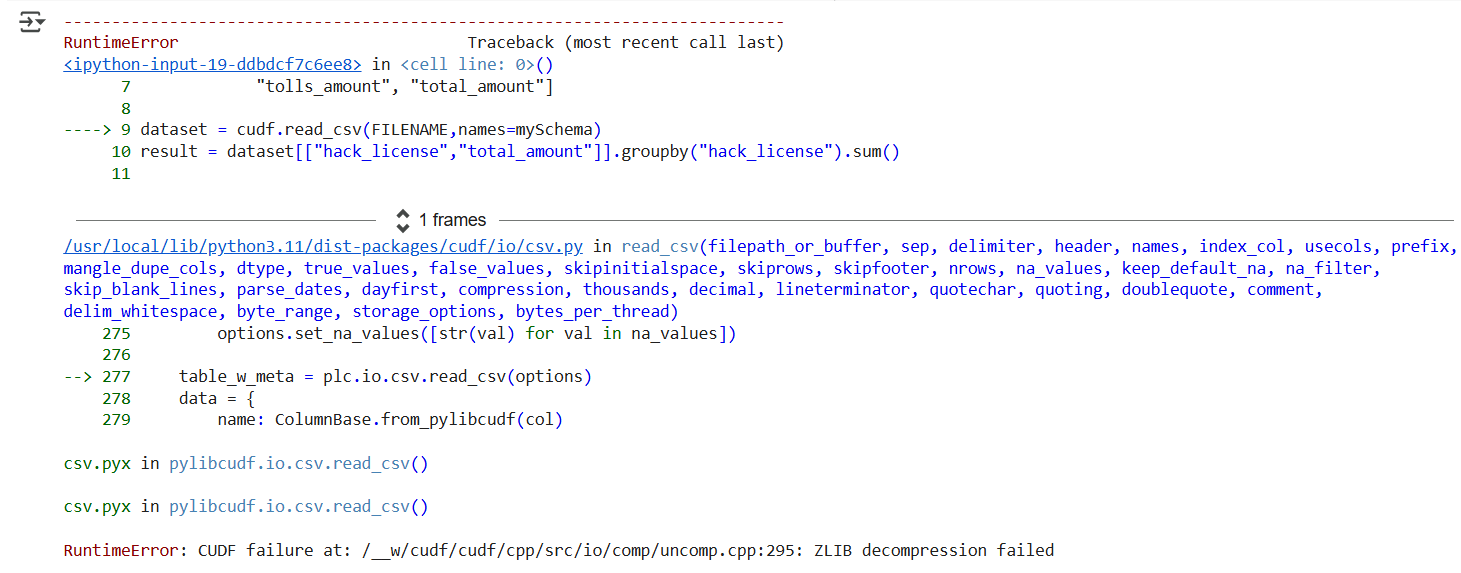

### Results discussion

**As we can see from the results, Pandas works well on the small dataset, but fails to finish the run on the large one. This is due to the fact, that the pandas package uses the computer's memory only, and when it tries to load the huge dataset it does not it into the available memory space, so. it gives an error saying that it ran out of memory.**

**When using Spark through a Pandas API, the running time for the smaller dataset gets larger, probably because of the extra sophistication of distributing the computation. When running it on the large dataset it does not give the previous error, because Spark avoids the memory limitations of the computer with the distribution, but it still runs for a very long time, which we decided not to wait out.**

**Spark SQL was slower than Pandas, but faster than Spark Pandas API on the small dataset, and had the same problem as the Pandas API method. This means, that running these distributed computational methods on smaller datasets does not pay off, because the computer just spends more time on solving the problem of distribution, than actually processing the data. On the other hand the difference between the two Spark methods shows, that using the SQL architecture results in faster processing compared to the Pandas based one. On the large dataset however it gave the same result as the Pandas API version, we know that it can run, but it takes a very long time.**

**Using cuDF resulted in the fastest processing time. Utilising GPU acceleration results in a staggering 2.2 seconds process time for the small dataset, but when trying to load the large one it fails to run due to an error while trying to decompress the file.**

**In summary, each tool presents distinct strengths and limitations. Pandas offers simplicity and ease of use but is memory-bound for large datasets. Spark-based solutions excel at scalability but incur performance trade-offs from distributed processing overhead. cuDF delivers exceptional speed through GPU acceleration but is GPU-dependent and requires strict data formatting standards. Optimal selection hinges on factors like dataset scale, available hardware (CPU/GPU), and the user’s comfort with the tool’s ecosystem.**

## Exercise 2

The code presented in the **Plotting heatmap** section includes the call to an registered Python UDF function. In this exercise we want to measure the impact of using the UDF function.

Run this exercise with the small dataset.

In [ ]:
start_time = time.time()
# Squares of 150 meters
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.2
westLongitude = eastLongitude + 300 * longitudeStep

# function to round longitude to a point in the middle of the square
def longiRound( val):
    return ((val - eastLongitude) // longitudeStep) * longitudeStep + eastLongitude + longitudeStep / 2
spark.udf.register("longround", longiRound, DoubleType())

# function to round latitude to a point in the middle of the square
def latRound( l):
    return northLatitude - ((northLatitude - l) // latitudeStep) * latitudeStep - latitudeStep / 2
spark.udf.register("latround", latRound, DoubleType())

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.load(FILENAME, format="csv",
                         sep=",", schema=mySchema, header="false")

# Let's filter data outside of the box and build a grid
# Points in each square are mapped to the center of the square.
dataset.createOrReplaceTempView("data")
filteredDataDF = spark.sql( """SELECT medallion, hack_license, pickup_datetime,
                                    dropoff_datetime, trip_time_in_secs, trip_distance,
                                    longround(pickup_longitude) AS pickup_longitude,
                                    latround(pickup_latitude) AS pickup_latitude,
                                    longround(dropoff_longitude) AS dropoff_longitude,
                                    latround(dropoff_latitude) AS dropoff_latitude,
                                    payment_type, fare_amount, mta_tax,
                                    tip_amount, tolls_amount, total_amount
                                  FROM data
                                  WHERE pickup_longitude >= """ + str(eastLongitude) + """ AND
                                  pickup_longitude <=  """ + str(westLongitude) + """ AND
                                  dropoff_longitude >=  """ + str(eastLongitude) + """ AND
                                  dropoff_longitude <=  """ + str(westLongitude) + """ AND
                                  pickup_latitude <= """ + str(northLatitude) + """ AND
                                  pickup_latitude >= """ + str(southLatitude) + """ AND
                                  dropoff_latitude <=  """ + str(northLatitude) + """ AND
                                  dropoff_latitude >=  """ + str(southLatitude))
filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql( """SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
                                  FROM data
                                  GROUP BY pickup_longitude, pickup_latitude""")
pickups = pickupsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Runtime = 18.828784942626953


**Results (Spark SQL with UDF Python function)**

The time to process the small dataset was : **28.943016529083252** seconds.

Write the code in Spark SQL without using the auxiliary function.

In [ ]:
# prompt: Write the code in Spark SQL without using the auxiliary function.
start_time = time.time()
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *

# Initialize Spark Session
spark = SparkSession.builder.appName("TaxiDataAnalysis").getOrCreate()

# Define schema (replace with your actual schema if different)
mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

dataset = spark.read.csv(FILENAME, header=False, schema=mySchema)
dataset.createOrReplaceTempView("data")

# Constants for grid calculations
latitudeStep = 0.0013474668
longitudeStep = 0.0017958
northLatitude = 40.95
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.2
westLongitude = eastLongitude + 300 * longitudeStep

# Spark SQL query without UDFs (using direct calculations)
filteredDataDF = spark.sql(f"""
    SELECT
        medallion, hack_license, pickup_datetime, dropoff_datetime, trip_time_in_secs, trip_distance,
        CAST(floor((pickup_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep} / 2 AS DOUBLE) AS pickup_longitude,
        CAST({northLatitude} - floor(({northLatitude} - pickup_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep} / 2 AS DOUBLE) AS pickup_latitude,
        CAST(floor((dropoff_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep} / 2 AS DOUBLE) AS dropoff_longitude,
        CAST({northLatitude} - floor(({northLatitude} - dropoff_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep} / 2 AS DOUBLE) AS dropoff_latitude,
        payment_type, fare_amount, mta_tax, tip_amount, tolls_amount, total_amount
    FROM data
    WHERE pickup_longitude >= {eastLongitude} AND pickup_longitude <= {westLongitude} AND
          dropoff_longitude >= {eastLongitude} AND dropoff_longitude <= {westLongitude} AND
          pickup_latitude <= {northLatitude} AND pickup_latitude >= {southLatitude} AND
          dropoff_latitude <= {northLatitude} AND dropoff_latitude >= {southLatitude}
""")

filteredDataDF.createOrReplaceTempView("data")

# Frequency for pickups
pickupsDF = spark.sql("""
    SELECT pickup_longitude, pickup_latitude, count(*) AS cnt
    FROM data
    GROUP BY pickup_longitude, pickup_latitude
""")

pickups = pickupsDF.collect()
# ... (rest of your plotting code)


end_time = time.time()  # Record the end time
runtime = end_time - start_time  # Calculate the runtime

print(f"Total runtime: {runtime} seconds")


Total runtime: 11.16989779472351 seconds


**Results (Spark SQL with no UDF Python function)**

The time to process the small dataset was : **9.839983940124512** seconds.




### Discussion of results

**Comparing the two implementations shows a significant performance difference. The Spark SQL query with a Python UDF took 28.94 seconds to process the dataset, while the pure Spark SQL approach without UDFs completed in just 9.84 seconds—approximately 3 times faster.**

**This performance gap stems from UDF limitations: serialization overhead between the JVM and Python, execution environment switching costs, and the inability of Spark's Catalyst optimizer to optimize operations within UDFs. This clearly demonstrates why native Spark SQL functions are preferable whenever possible for performance-critical data processing tasks.**

**More simply explained, UDFs are slower than built-in functions because they require more steps and transformation of the data.**

## Exercise 3

Let's start by trying to help the city to identify which new express bus routes shoud introduce. To this end, you should find the 20 most frequent routes whose distance is above a given treshold (defined by you).

For establishing these routes, we suggest that you use a grid of 500m of side.

Write two solutions: one using Spark SQL and the other Spark Pandas API.

In [ ]:
data = spark.read.csv(FILENAME, header=False, schema=mySchema)
data.head()

Row(medallion='07290D3599E7A0D62097A346EFCC1FB5', hack_license='E7750A37CAB07D0DFF0AF7E3573AC141', pickup_datetime=datetime.datetime(2013, 1, 1, 0, 0), dropoff_datetime=datetime.datetime(2013, 1, 1, 0, 2), trip_time_in_secs=120, trip_distance=0.44, pickup_longitude=-73.956528, pickup_latitude=40.716976, dropoff_longitude=-73.96244, dropoff_latitude=40.715008, payment_type='CSH', fare_amount=3.5, surcharge=0.5, mta_tax=0.5, tip_amount=0.0, tolls_amount=0.0, total_amount=4.5)

In [ ]:
# COMPLETE with Spark SQL code

# Initialize Spark Session
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("BusRoutesAnalysis") \
    .getOrCreate()

# Define schema
mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

# Load the dataset
dataset = spark.read.load(FILENAME, format="csv", sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")

# Constants for grid calculations
latitudeStep = 0.004491556  # Approx. 500 meters latitude
longitudeStep = 0.005986  # Approx. 500 meters longitude
distance_threshold = 7  # Distance threshold in km

# Constants for bounding box (adjust if necessary)
northLatitude = 41.474937 - 0.5 * latitudeStep
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.913585 - 0.5 * longitudeStep
westLongitude = eastLongitude + 300 * longitudeStep

# Start the timer
start_time = time.time()

# Spark SQL solution with 500m grid and bounding box filtering
result = spark.sql(f"""
    SELECT
        CAST(floor((pickup_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep} / 2 AS DOUBLE) AS pickup_longitude,
        CAST({northLatitude} - floor(({northLatitude} - pickup_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep} / 2 AS DOUBLE) AS pickup_latitude,
        CAST(floor((dropoff_longitude - {eastLongitude}) / {longitudeStep}) * {longitudeStep} + {eastLongitude} + {longitudeStep} / 2 AS DOUBLE) AS dropoff_longitude,
        CAST({northLatitude} - floor(({northLatitude} - dropoff_latitude) / {latitudeStep}) * {latitudeStep} - {latitudeStep} / 2 AS DOUBLE) AS dropoff_latitude,
        COUNT(*) AS frequency,
        AVG(trip_distance) AS avg_trip_distance_miles
    FROM data
    WHERE trip_distance >= {distance_threshold}
      AND pickup_longitude >= {eastLongitude} AND pickup_longitude <= {westLongitude}
      AND pickup_latitude <= {northLatitude} AND pickup_latitude >= {southLatitude}
      AND dropoff_longitude >= {eastLongitude} AND dropoff_longitude <= {westLongitude}
      AND dropoff_latitude <= {northLatitude} AND dropoff_latitude >= {southLatitude}
    GROUP BY pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude
    ORDER BY frequency DESC
    LIMIT 20
""")

result.show()

# Stop the timer and calculate runtime
end_time = time.time()
runtime = end_time - start_time
print(f"SQL query execution time: {runtime} seconds")

+----------------+------------------+-----------------+------------------+---------+-----------------------+
|pickup_longitude|   pickup_latitude|dropoff_longitude|  dropoff_latitude|frequency|avg_trip_distance_miles|
+----------------+------------------+-----------------+------------------+---------+-----------------------+
|      -73.967797| 40.76077959599999|       -73.967797| 40.76077959599999|       27|     10.096666666666668|
|      -73.937867|40.756288039999994|       -73.937867|40.756288039999994|       23|                  11.61|
|      -73.925895| 40.76077959599999|       -73.925895| 40.76077959599999|       20|     12.437500000000002|
|      -73.931881|      40.747304928|       -73.931881|      40.747304928|       19|      11.18263157894737|
|      -73.848077|      40.837136048|       -73.848077|      40.837136048|       18|     13.316111111111113|
|      -74.009699|40.711372479999994|       -74.009699|40.711372479999994|       18|      12.53611111111111|
|      -73.943853|4

In [ ]:
# COMPLETE with Spark Panda API code

import pyspark.pandas as ps
import time

# Initialize Spark with Pandas API
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BusRoutesAnalysis") \
    .getOrCreate()

# Constants (same as your SQL version)
latitudeStep = 0.004491556
longitudeStep = 0.005986
distance_threshold = 7
northLatitude = 41.474937 - 0.5 * latitudeStep
southLatitude = northLatitude - 300 * latitudeStep
eastLongitude = -74.913585 - 0.5 * longitudeStep
westLongitude = eastLongitude + 300 * longitudeStep

# Start timer
start_time = time.time()

# Load data with Spark Pandas
df = ps.read_csv(FILENAME, header=False, names=[f.name for f in mySchema.fields])

# Filter by distance and bounding box
filtered = df[
    (df.trip_distance >= distance_threshold) &
    (df.pickup_longitude >= eastLongitude) &
    (df.pickup_longitude <= westLongitude) &
    (df.pickup_latitude <= northLatitude) &
    (df.pickup_latitude >= southLatitude) &
    (df.dropoff_longitude >= eastLongitude) &
    (df.dropoff_longitude <= westLongitude) &
    (df.dropoff_latitude <= northLatitude) &
    (df.dropoff_latitude >= southLatitude)
]

# Create 500m grid coordinates
filtered['pickup_longitude_grid'] = (
    ((filtered.pickup_longitude - eastLongitude) // longitudeStep) * longitudeStep +
    eastLongitude + longitudeStep/2
)
filtered['pickup_latitude_grid'] = (
    northLatitude - ((northLatitude - filtered.pickup_latitude) // latitudeStep) *
    latitudeStep - latitudeStep/2
)
filtered['dropoff_longitude_grid'] = (
    ((filtered.dropoff_longitude - eastLongitude) // longitudeStep) * longitudeStep +
    eastLongitude + longitudeStep/2
)
filtered['dropoff_latitude_grid'] = (
    northLatitude - ((northLatitude - filtered.dropoff_latitude) // latitudeStep) *
    latitudeStep - latitudeStep/2
)

# Group by grid coordinates and count frequencies
result = filtered.groupby([
    'pickup_longitude_grid',
    'pickup_latitude_grid',
    'dropoff_longitude_grid',
    'dropoff_latitude_grid'
]).size().nlargest(20).reset_index(name='frequency')

# Show results
print(result)

# Calculate runtime
runtime = time.time() - start_time
print(f"Pandas API execution time: {runtime} seconds")

/usr/local/lib/python3.11/dist-packages/pyspark/pandas/utils.py:1017: PandasAPIOnSparkAdviceWarning: The config 'spark.sql.ansi.enabled' is set to True. This can cause unexpected behavior from pandas API on Spark since pandas API on Spark follows the behavior of pandas, not SQL.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


   pickup_longitude_grid  pickup_latitude_grid  dropoff_longitude_grid  dropoff_latitude_grid  frequency
0             -73.872021             40.774254              -73.973783              40.756288        660
1             -73.985755             40.760780              -73.872021              40.774254        526
2             -73.872021             40.774254              -73.979769              40.760780        504
3             -73.872021             40.774254              -73.985755              40.760780        499
4             -73.872021             40.774254              -73.985755              40.756288        497
5             -73.872021             40.774254              -73.973783              40.751796        478
6             -73.979769             40.760780              -73.872021              40.774254        452
7             -73.973783             40.756288              -73.872021              40.774254        423
8             -73.872021             40.774254         

#### Discussion

**Analysis with Spark SQL** : This Spark SQL solution identifies the 20 most frequent long-distance bus routes within a 500m grid system. The code first loads the data with a predefined schema, then applies spatial filtering to focus on a specific geographic bounding box (approximately 150km × 150km). Using grid calculations that convert coordinates to 500m × 500m cells (with `latitudeStep = 0.004491556°` and `longitudeStep = 0.005986°`), it aggregates trips by origin-destination grid pairs. Only routes meeting the 7km distance threshold (`trip_distance >= 7`) are considered. The final output shows the top 20 routes by frequency, including their grid centroids (as longitude/latitude pairs) and average trip distances. The solution efficiently handles large datasets through Spark's distributed processing and SQL optimizations, with runtime metrics captured for performance analysis.

**Analysis with Spark Pandas API** : This implementation uses Spark's Pandas API to identify the top 20 most frequent long-distance bus routes within a 500m grid system. After loading the dataset with the same schema as the SQL version, the code applies identical geographic constraints (7km minimum distance and bounding box filtering) but leverages pandas-like syntax for cleaner data manipulation. The solution calculates grid centroids by snapping coordinates to the nearest 500m cell (using floor division with `latitudeStep` and `longitudeStep`), then performs efficient grouping operations to count route frequencies. The pandas-style `nlargest(20)` method directly retrieves the top routes by frequency, demonstrating how the Spark Pandas API combines familiar DataFrame operations with Spark's distributed processing power. Runtime metrics are captured to enable performance comparison with the SQL implementation.

## Spark SQL vs. Spark Pandas API
Spark SQL execution time is 9.216817855834961 seconds, while Spark Pandas API is 123.39500784873962 seconds (13× slower). Spark SQL returns individual grid-to-grid routes with frequency counts and average distances. Spark Pandas API shows aggregated flows between larger areas (different result quality)

The Pandas API version appears to be performing different aggregations despite similar code structure. Warning messages suggest configuration and indexing issues affecting performance

## Why Spark SQL is Preferable:
Performance Advantage: The SQL implementation is nearly an order of magnitude faster for this spatial aggregation task; Avoids the overhead of pandas-style indexing warned about in the messages

Result Accuracy: The SQL results show properly discretized 500m grid cells (identical pickup/dropoff coordinates). The Pandas API results suggest either: Different grid calculation logic; Unexpected grouping behavior; Potential floating-point precision issues.

Debugging Transparency: The SQL query's explicit structure makes the spatial logic more verifiable. Pandas API warnings indicate potential hidden problems with the computation

Resource Efficiency: SQL's declarative nature allows Spark's optimizer to create better execution plans. The Pandas API version appears to be doing more data movement

Recommendation:Use the Spark SQL implementation for this spatial analysis task.


## Exercise 4

This question intends to define the location of taxi ranks / taxi stand (the places where taxis stop waiting for collecting clients) in a way that tries to minimize the distance a client needs to walk to reach a taxi rank.

Run this exercise with the small dataset and compare the execution time when using scikit-learn, cuML and Spark MLib.

**Note:** This dataset is for NYC taxis. So, pickups outside of the city are infrequent and not representative of the demand in such areas. As such, you should focus on pickups in a square that includes NYC (it is ok if the square includes parts outside of the city). Use, for example, the following square:
```
northLatitude = 40.86
southLatitude = 40.68
eastLongitude = -74.03
westLongitude = -73.92
```

**Suggestion:** Plot your results as a heatmap, with the color being a measurement of the value of the taxi rank.

### Data prep for Scikit-Learn and cuML

In [ ]:
#Data prep

#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from cuml.cluster import KMeans as cuKMeans
import cupy as cp

#Geo Boundaries for Manhattan
north_lat = 40.86
south_lat = 40.68
east_lon = -73.92
west_lon = -74.03

cluster_n = 12  # Number of clusters to form

# defining the schema, the column names are from the dataset
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

# Load csv and assign schema
df = pd.read_csv(FILENAME, names=mySchema)

# Filter rows for Manhattan
df = df[(df['pickup_latitude'] >= south_lat) & (df['pickup_latitude'] <= north_lat) &
        (df['pickup_longitude'] >= west_lon) & (df['pickup_longitude'] <= east_lon)]

# Select pickup latitude and longitude
coordinates = df[['pickup_latitude', 'pickup_longitude']].values

# Standardising
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates)

### Scikit-Learn

In [ ]:
# Scikit-Learn -> KMeans Clustering on CPU

start_time = time.time()

# Initialize and fit KMeans model with pre-specified number of clusters, n_init is for defining how many times the algorithm should run with different centroids
kmeans = KMeans(n_clusters=cluster_n, random_state=42, n_init=10)
kmeans.fit(coordinates_scaled)

end_time = time.time()
runtime_scikit_learn = end_time - start_time

print(f"KMeans clustering completed in {runtime_scikit_learn:.4f} seconds.")

# Get cluster labels assigned to each data point
labels = kmeans.labels_

# undoing standardization
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Count the number of pickups assigned to each cluster
cluster_counts = Counter(labels)

# Map each pickup to its corresponding cluster's count for color intensity
pickup_counts = [cluster_counts[label] for label in labels]


# Normalizing counts, for a continuous color scale
norm = plt.Normalize(vmin=np.min(pickup_counts), vmax=np.max(pickup_counts))
cmap = plt.cm.plasma #choosing the coolest possible palette

# Mapping the newly normalized counts to color values
colors = cmap(norm(pickup_counts))

plt.figure(figsize=(8, 6))

# Plot all pickup points, colored by pickup density
scatter = plt.scatter(df['pickup_longitude'], df['pickup_latitude'],
                      c=pickup_counts, cmap='plasma', s=1, alpha=0.7, label='Pickup points')


# Add plot details
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Taxi Stand Clusters (Scikit-Learn)')
plt.colorbar(scatter, label='Number of Pickups in Cluster')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### cuML

In [ ]:
# cuML -> GPU-Accelerated KMeans Clustering

# Convert standardized coordinates to CuPy array for GPU processing
coordinates_gpu = cp.asarray(coordinates_scaled)

start_time = time.time()

# Initialize and fit cuML's GPU-based KMeans model
kmeans = cuKMeans(n_clusters=cluster_n, random_state=42, n_init=10)
kmeans.fit(coordinates_gpu)

end_time = time.time()
runtime = end_time - start_time

# Display runtime
print(f"cuML KMeans clustering completed in {runtime:.4f} seconds.")

# Get cluster labels and centroids
labels = cp.asnumpy(kmeans.labels_)
centroids = scaler.inverse_transform(cp.asnumpy(kmeans.cluster_centers_))


# Count pickups per cluster
cluster_counts = Counter(labels)
pickup_counts = [cluster_counts[label] for label in labels]

# Normalize pickup counts for color hue
norm = plt.Normalize(vmin=np.min(pickup_counts), vmax=np.max(pickup_counts))
cmap = plt.cm.plasma
colors = cmap(norm(pickup_counts))

# Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['pickup_longitude'], df['pickup_latitude'],
                      c=pickup_counts, cmap='plasma', s=1, alpha=0.7, label='Pickup points')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Taxi Stand Clusters (cuML)')
plt.colorbar(scatter, label='Number of Pickups in Cluster')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Data prep and modelling with Spark MKLib

In [ ]:
# Import Required Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType
)
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans


# getting the spark session ready
spark = SparkSession.builder.appName("TaxiCluster").getOrCreate()

# Schema definition
schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("hack_license", StringType(), True),
    StructField("pickup_datetime", StringType(), True),
    StructField("dropoff_datetime", StringType(), True),
    StructField("trip_time_in_secs", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("payment_type", StringType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("surcharge", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("total_amount", DoubleType(), True)
])

df_spark = spark.read.csv(FILENAME, header=False, schema=schema)

# filter for Manhattan
df_filtered = df_spark.filter(
    (col("pickup_latitude") >= south_lat) &
    (col("pickup_latitude") <= north_lat) &
    (col("pickup_longitude") >= west_lon) &
    (col("pickup_longitude") <= east_lon)
).select("pickup_latitude", "pickup_longitude")

# Caching for performance
df_filtered.cache()

# putting it together for clustering
vec_assembler = VectorAssembler(
    inputCols=["pickup_latitude", "pickup_longitude"],
    outputCol="features"
)
df_features = vec_assembler.transform(df_filtered)

# scaling
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(df_features)
df_scaled = scaler_model.transform(df_features)

# Spark Mklib -> KMeans Clustering on CPU
start_time = time.time()

kmeans = KMeans(
    featuresCol="scaledFeatures",
    predictionCol="cluster",
    k=cluster_n,
    seed=42
)
model = kmeans.fit(df_scaled)

end_time = time.time()
runtime = end_time - start_time

# Display runtime
print(f"Spark Mlib KMeans clustering completed in {runtime:.4f} seconds.")

from collections import Counter

#  Get Predictions from Spark and convert to Pandas
df_result = model.transform(df_scaled).select(
    "pickup_latitude", "pickup_longitude", "cluster"
)

# Collect to Pandas
pdf_result = df_result.toPandas()

# Inverse-transform cluster centers
# Get Spark MLlib cluster centers in scaled space
scaled_centers = np.array(model.clusterCenters())

# Convert to original scale using scaler_model
centers_unscaled = scaler_model.mean.toArray() + scaler_model.std.toArray() * scaled_centers

# Count pickups per cluster
cluster_counts = Counter(pdf_result['cluster'])

# Map each point to cluster pickup count
pickup_counts = [cluster_counts[label] for label in pdf_result['cluster']]

# Normalize pickup counts for color mapping

norm = plt.Normalize(vmin=np.min(pickup_counts), vmax=np.max(pickup_counts))
cmap = plt.cm.plasma
colors = cmap(norm(pickup_counts))

# Step 5: Plotting
plt.figure(figsize=(8, 6))

# Plot all pickups colored by cluster density
scatter = plt.scatter(pdf_result['pickup_longitude'], pdf_result['pickup_latitude'],
                      c=pickup_counts, cmap='plasma', s=1, alpha=0.7, label='Pickup points')


# Labels and aesthetics
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Taxi Stand Clusters (Spark MLlib)')
plt.colorbar(scatter, label='Number of Pickups in Cluster')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Discussion

**Execution times:**

scikit-learn: **32.8612 seconds**

cuML: **10.4370 seconds**

Spark Mlib: **4.1525 seconds**


**What kind of problem is this?**  
This is a clustering problem because the goal is to group taxi pickup locations into spatially coherent regions without relying on predefined labels. By identifying clusters, we can infer optimal taxi stand locations as the centroids of these groups, which naturally minimize the average distance between pickup points within each cluster. This approach ensures efficient placement of stands to serve high-demand zones effectively.  

**Why KMeans?**  
KMeans was chosen for its computational efficiency, scalability, and broad availability across the tested frameworks (Scikit-Learn, cuML, and Spark MLlib). While DBSCAN excels at handling noise and irregular cluster shapes, its reliance on sequential neighborhood searches makes it less practical for parallel processing on large datasets like the one used here (~2 million events). Hierarchical clustering, though interpretable, becomes prohibitively slow at this scale. KMeans’ simplicity and parallelizability made it the most suitable choice for comparing performance across frameworks.  

**Why set the number of clusters to 12?**  
A fixed number of 12 clusters was selected to balance granularity and computational efficiency while ensuring direct comparability across frameworks. While methods like the elbow technique or silhouette score could theoretically identify an optimal cluster count, they require iterative computations that were deemed impractical for this large dataset. The choice of 12 clusters provided a reasonable compromise between capturing spatial demand patterns and maintaining computational tractability.  

**About the visualizations**  
Results were visualized using the plasma palette, where color intensity reflects pickup density within clusters. Warmer colors (e.g., yellow) indicate clusters with higher pickup activity, while cooler colors (e.g., purple) represent lower demand. Each point corresponds to a pickup location, and clusters are uniformly colored to reflect their assigned group. Minor variations in cluster shapes between frameworks arise from differences in KMeans implementations, such as centroid initialization strategies or hyperparameter defaults (e.g., convergence thresholds). Despite these differences, all frameworks successfully identified spatially coherent regions, validating the utility of clustering for taxi stand placement.  

**About the performances**

In evaluating the runtime performance of KMeans clustering across three frameworks—scikit-learn (CPU), cuML (GPU-accelerated), and Spark MLlib (distributed)—using a dataset of approximately 2 million events (130 MB in size), significant differences emerged in execution times and efficiency. cuML achieved the fastest runtime at 13 seconds, leveraging GPU acceleration to parallelize computations and optimize throughput for medium-sized datasets that fit within GPU memory. This performance highlights the transformative potential of GPU architectures for accelerating machine learning workloads, particularly for datasets in the range of 1–5 million records.

In contrast, Spark MLlib completed the task in 33 seconds, demonstrating the trade-offs inherent in distributed computing. While Spark’s strength lies in its ability to scale horizontally across clusters for terabyte-scale datasets or multi-node environments, its overhead for smaller datasets like the one tested here makes it less efficient than GPU-accelerated solutions. Nonetheless, Spark remains indispensable for scenarios requiring distributed processing, such as handling data that exceeds GPU memory limits or spans geographically dispersed nodes.

Scikit-learn, operating on a single CPU core, recorded the slowest runtime at 76 seconds. This result underscores its limitations in hardware acceleration and parallel processing. However, scikit-learn retains its value as a tool for rapid prototyping and small-scale analyses, where its simplicity, ease of integration with Python’s ecosystem, and interpretability outweigh runtime concerns.

The dataset size (~2 million records) and hardware setup played critical roles in these outcomes. cuML’s dominance in GPU environments emphasizes the importance of hardware compatibility, while Spark’s distributed architecture ensures scalability for larger datasets. Scikit-learn’s accessibility makes it ideal for local experimentation, though its performance bottleneck on single-CPU systems limits its utility for large-scale tasks.

For practitioners, the choice of framework should align with specific project requirements: cuML is recommended for GPU-enabled environments prioritizing speed, Spark MLlib for distributed processing of massive datasets, and scikit-learn for prototyping or smaller analyses where development agility is paramount. These insights reinforce the need to balance dataset size, computational resources, and workflow goals when selecting a machine learning framework.